# Lab 4: TinyML Lab – Quantization-Aware Training (QAT)

**Option B:** CIFAR-10 + MobileNetV2

**Aim:** To implement Quantization-Aware Training (QAT) on a TinyML model using CIFAR-10 and MobileNetV2, and compare it with full INT8 Post-Training Quantization (PTQ).

**Models compared:** Float32 baseline, Full INT8 PTQ, Full INT8 QAT  
**Metrics:** Model size (KB), test accuracy (%), average inference latency (ms)

### 1. Environment Setup

Install TensorFlow Model Optimization (`tf-keras` is the legacy Keras package that this toolkit needs on recent TensorFlow versions), then set `TF_USE_LEGACY_KERAS` **before** importing TensorFlow. Random seeds are fixed for reproducibility.

In [1]:
!pip install -q tensorflow-model-optimization tf-keras

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import random
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 17.4 MB/s eta 0:00:00


### 2. Load CIFAR-10 Dataset

CIFAR-10 is loaded with `tf.keras.datasets.cifar10`. A random subset of **5000 training** and **1000 test** images is used, as specified in the lab.

170498071/170498071 [==============================] - 103s 1us/step
Full CIFAR-10 train / test : (50000, 32, 32, 3) (10000, 32, 32, 3)
Subset train images        : (5000, 32, 32, 3) labels: (5000,)
Subset test images         : (1000, 32, 32, 3) labels: (1000,)
Image dtype / pixel range  : uint8 [0, 255]
Classes                    : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train images per class     : [473, 542, 535, 482, 523, 473, 502, 469, 518, 483]
Test images per class      : [107, 108, 85, 112, 108, 98, 121, 72, 91, 98]


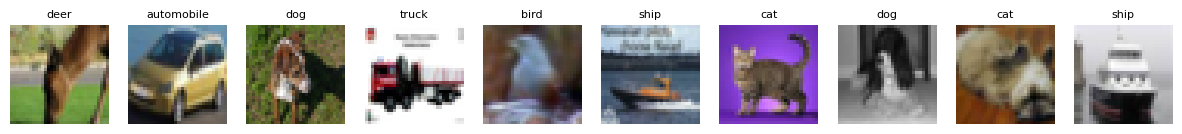

In [2]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

NUM_TRAIN, NUM_TEST = 5000, 1000
rng = np.random.default_rng(SEED)
train_idx = rng.permutation(len(x_train_full))[:NUM_TRAIN]
test_idx = rng.permutation(len(x_test_full))[:NUM_TEST]

x_train_raw, y_train_all = x_train_full[train_idx], y_train_full[train_idx].flatten()
x_test_raw,  y_test      = x_test_full[test_idx],   y_test_full[test_idx].flatten()

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]
NUM_CLASSES = len(class_names)

print("Full CIFAR-10 train / test :", x_train_full.shape, x_test_full.shape)
print("Subset train images        :", x_train_raw.shape, "labels:", y_train_all.shape)
print("Subset test images         :", x_test_raw.shape, "labels:", y_test.shape)
print("Image dtype / pixel range  :", x_train_raw.dtype, f"[{x_train_raw.min()}, {x_train_raw.max()}]")
print("Classes                    :", class_names)
print("Train images per class     :", np.bincount(y_train_all).tolist())
print("Test images per class      :", np.bincount(y_test).tolist())

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train_raw[i])
    ax.set_title(class_names[y_train_all[i]], fontsize=8)
    ax.axis("off")
plt.show()

### 3. Image Preprocessing

CIFAR-10 images (32×32×3) are resized to 96×96×3 and passed through MobileNetV2's own `preprocess_input`, which scales pixels to [-1, 1]. Labels stay as integer class ids (0–9) and are used with sparse categorical cross-entropy.

In [3]:
IMG_SIZE = 96

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

# quick check on one image
sample_img, _ = preprocess(x_train_raw[0], y_train_all[0])
print("Before:", x_train_raw[0].shape, "range", (x_train_raw[0].min(), x_train_raw[0].max()))
print("After :", sample_img.shape, f"range ({sample_img.numpy().min():.2f}, {sample_img.numpy().max():.2f})")

Before: (32, 32, 3) range (np.uint8(0), np.uint8(227))
After : (96, 96, 3) range (-1.00, 0.78)


### 4. Dataset Pipeline

500 of the 5000 training images are held out for validation. Each `tf.data` pipeline applies preprocessing, batching and prefetching; only the training pipeline is shuffled. The preprocessed test set is also kept as a NumPy array so that the TFLite models can be fed the exact same samples later.

In [4]:
BATCH_SIZE = 32
VAL_SIZE = 500
AUTOTUNE = tf.data.AUTOTUNE

x_val_raw, y_val = x_train_raw[:VAL_SIZE], y_train_all[:VAL_SIZE]
x_tr_raw,  y_tr  = x_train_raw[VAL_SIZE:], y_train_all[VAL_SIZE:]

def make_dataset(images, labels, training=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if training:
        ds = ds.shuffle(len(images), seed=SEED)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_dataset(x_tr_raw, y_tr, training=True)
val_ds   = make_dataset(x_val_raw, y_val)
test_ds  = make_dataset(x_test_raw, y_test)

# Preprocessed test set as NumPy (same images/labels used for ALL three models)
test_images = np.concatenate([xb.numpy() for xb, _ in test_ds])
test_labels = np.concatenate([yb.numpy() for _, yb in test_ds])

# Representative samples (100 training images) for PTQ calibration
rep_images = next(iter(make_dataset(x_tr_raw, y_tr, batch_size=100)))[0].numpy()

print("Train / Val / Test samples:", len(x_tr_raw), len(x_val_raw), len(x_test_raw))
print("Test array :", test_images.shape, test_images.dtype)
print("Rep. array :", rep_images.shape)

Train / Val / Test samples: 4500 500 1000
Test array : (1000, 96, 96, 3) float32
Rep. array : (100, 96, 96, 3)


### 5. Build MobileNetV2 Baseline

MobileNetV2 (`alpha=0.35`, ImageNet weights, 96×96×3 input) is used as the backbone. A global-average-pooling layer, dropout and a 10-class softmax layer are added on top. The new model is built directly from `base.input` / `base.output`, so it is one flat functional model with no nested Keras model.

In [5]:
base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    alpha=0.35,
    include_top=False,
    weights="imagenet",
)

x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

baseline_model = tf.keras.Model(inputs=base.input, outputs=outputs, name="mobilenetv2_cifar10")

print("Nested Model inside model:", any(isinstance(l, tf.keras.Model) for l in baseline_model.layers))
print("Output shape             :", baseline_model.output_shape)
print("Total parameters         :", baseline_model.count_params())

2019640/2019640 [==============================] - 1s 1us/step
Nested Model inside model: False
Output shape             : (None, 10)
Total parameters         : 423018


### 6. Train Baseline Model

The baseline is trained for 10 epochs with Adam (learning rate 1e-4) and sparse categorical cross-entropy. The weights of the epoch with the best validation accuracy are kept, so the baseline is not left at a noisy last epoch. Training/validation accuracy and loss are stored in `baseline_history`.

In [6]:
class RestoreBestWeights(tf.keras.callbacks.Callback):
    """Remembers the weights of the epoch with the best validation accuracy and restores them when training ends."""
    def __init__(self):
        super().__init__()
        self.best_acc, self.best_epoch, self.best_weights = -1.0, 0, None

    def on_epoch_end(self, epoch, logs=None):
        if logs["val_accuracy"] > self.best_acc:
            self.best_acc, self.best_epoch = logs["val_accuracy"], epoch + 1
            self.best_weights = self.model.get_weights()

    def on_train_end(self, logs=None):
        self.model.set_weights(self.best_weights)
        print(f"Restored weights of epoch {self.best_epoch} (validation accuracy {self.best_acc * 100:.2f}%)")

BASELINE_EPOCHS = 10

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_best = RestoreBestWeights()
baseline_history = baseline_model.fit(
    train_ds, validation_data=val_ds, epochs=BASELINE_EPOCHS,
    callbacks=[baseline_best], verbose=2
)

Epoch 1/10
141/141 - 33s - loss: 1.4289 - accuracy: 0.5169 - val_loss: 1.0750 - val_accuracy: 0.6140 - 33s/epoch - 235ms/step
Epoch 2/10
141/141 - 4s - loss: 0.7073 - accuracy: 0.7624 - val_loss: 0.8789 - val_accuracy: 0.7080 - 4s/epoch - 30ms/step
Epoch 3/10
141/141 - 4s - loss: 0.5117 - accuracy: 0.8231 - val_loss: 0.8233 - val_accuracy: 0.7120 - 4s/epoch - 28ms/step
Epoch 4/10
141/141 - 4s - loss: 0.3860 - accuracy: 0.8727 - val_loss: 0.8573 - val_accuracy: 0.6980 - 4s/epoch - 26ms/step
Epoch 5/10
141/141 - 6s - loss: 0.2958 - accuracy: 0.9029 - val_loss: 0.8803 - val_accuracy: 0.7080 - 6s/epoch - 41ms/step
Epoch 6/10
141/141 - 4s - loss: 0.2435 - accuracy: 0.9251 - val_loss: 0.8795 - val_accuracy: 0.6940 - 4s/epoch - 25ms/step
Epoch 7/10
141/141 - 4s - loss: 0.1959 - accuracy: 0.9380 - val_loss: 1.0067 - val_accuracy: 0.6800 - 4s/epoch - 32ms/step
Epoch 8/10
141/141 - 4s - loss: 0.1513 - accuracy: 0.9551 - val_loss: 1.0071 - val_accuracy: 0.6780 - 4s/epoch - 26ms/step
Epoch 9/10
14

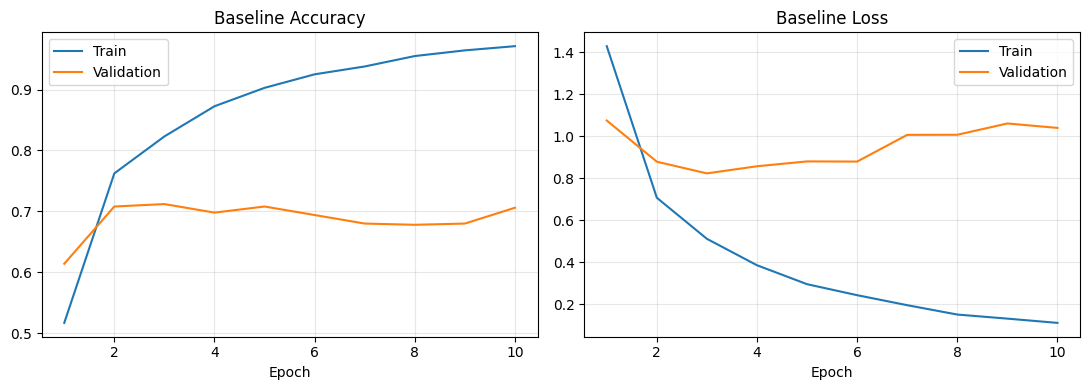

In [7]:
h = baseline_history.history
epochs_range = range(1, BASELINE_EPOCHS + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(epochs_range, h["accuracy"], label="Train")
ax[0].plot(epochs_range, h["val_accuracy"], label="Validation")
ax[0].set_title("Baseline Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(epochs_range, h["loss"], label="Train")
ax[1].plot(epochs_range, h["val_loss"], label="Validation")
ax[1].set_title("Baseline Loss"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 7. Evaluate Float32 Baseline

The Keras model is evaluated on the test subset. It is then converted to a Float32 TFLite file so its size and latency are measured the same way as the INT8 models.

The helper functions below are used for **all three models**: file size from the `.tflite` file, accuracy on the same 1000 test images, and latency as the average time of `interpreter.invoke()` over all 1000 single-image runs (1 thread, after 10 warm-up runs; loading/conversion time and input quantization are excluded). INT8 inputs are quantized with the model's own scale and zero-point, and INT8 outputs are dequantized.

In [8]:
results = {}   # filled step by step: size, accuracy, latency

def get_size_kb(path):
    return os.path.getsize(path) / 1024

def evaluate_tflite(model_path, images, labels, warmup=10):
    """Returns (accuracy %, average latency in ms) for a .tflite model."""
    interpreter = tf.lite.Interpreter(model_path=model_path, num_threads=1)
    interpreter.allocate_tensors()
    inp = interpreter.get_input_details()[0]
    out = interpreter.get_output_details()[0]
    in_scale, in_zp = inp["quantization"]
    out_scale, out_zp = out["quantization"]

    def prepare(sample):
        x = sample[np.newaxis, ...]
        if inp["dtype"] == np.int8:                      # float -> int8 using scale / zero-point
            x = np.round(x / in_scale + in_zp)
            return np.clip(x, -128, 127).astype(np.int8)
        return x.astype(np.float32)

    for i in range(warmup):                              # warm-up (not timed)
        interpreter.set_tensor(inp["index"], prepare(images[i]))
        interpreter.invoke()

    predictions, latencies = [], []
    for sample in images:
        interpreter.set_tensor(inp["index"], prepare(sample))
        start = time.perf_counter()
        interpreter.invoke()
        latencies.append((time.perf_counter() - start) * 1000)
        y = interpreter.get_tensor(out["index"])[0]
        if out["dtype"] == np.int8:                      # int8 -> float using scale / zero-point
            y = (y.astype(np.float32) - out_zp) * out_scale
        predictions.append(np.argmax(y))

    accuracy = 100.0 * np.mean(np.array(predictions) == labels)
    return accuracy, float(np.mean(latencies))

def inspect_tflite(model_path):
    """Prints input/output dtype and the tensor-type breakdown of a .tflite model."""
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    inp = interpreter.get_input_details()[0]
    out = interpreter.get_output_details()[0]
    print("Input  dtype:", np.dtype(inp["dtype"]).name, "| (scale, zero_point) =", inp["quantization"])
    print("Output dtype:", np.dtype(out["dtype"]).name, "| (scale, zero_point) =", out["quantization"])
    counts = Counter(np.dtype(t["dtype"]).name for t in interpreter.get_tensor_details())
    print("Tensor dtypes in model:", dict(counts))
    return inp["dtype"], out["dtype"]

In [9]:
# Keras (float32) accuracy on the test subset
_, float_keras_acc = baseline_model.evaluate(test_ds, verbose=0)
print(f"Float32 Keras test accuracy: {float_keras_acc * 100:.2f}%")

# Convert to Float32 TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(baseline_model)
tflite_float32 = converter.convert()
with open("model_float32.tflite", "wb") as f:
    f.write(tflite_float32)

# Benchmark with the common methodology
acc, lat = evaluate_tflite("model_float32.tflite", test_images, test_labels)
results["Float32 Baseline"] = {"Size (KB)": get_size_kb("model_float32.tflite"),
                               "Test Accuracy (%)": acc, "Avg Latency (ms)": lat}
print("Float32 TFLite ->", {k: round(v, 3) for k, v in results["Float32 Baseline"].items()})

Float32 Keras test accuracy: 71.30%


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Float32 TFLite -> {'Size (KB)': 1596.961, 'Test Accuracy (%)': np.float64(71.3), 'Avg Latency (ms)': 0.475}


### 8. Full INT8 Post-Training Quantization (PTQ)

The trained baseline is converted to **full integer** INT8 TFLite. A representative dataset (100 training images) lets the converter calibrate activation ranges. Restricting the ops to `TFLITE_BUILTINS_INT8` and setting input/output types to `int8` makes the whole model INT8, not just the weights.

In [10]:
def representative_dataset():
    for i in range(len(rep_images)):
        yield [rep_images[i:i + 1]]

converter = tf.lite.TFLiteConverter.from_keras_model(baseline_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_ptq = converter.convert()

with open("model_ptq_int8.tflite", "wb") as f:
    f.write(tflite_ptq)

print(f"model_ptq_int8.tflite saved: {get_size_kb('model_ptq_int8.tflite'):.2f} KB")
in_dtype, out_dtype = inspect_tflite("model_ptq_int8.tflite")
assert in_dtype == np.int8 and out_dtype == np.int8, "PTQ model is not full INT8"

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


model_ptq_int8.tflite saved: 609.98 KB
Input  dtype: int8 | (scale, zero_point) = (0.007843137718737125, -1)
Output dtype: int8 | (scale, zero_point) = (0.00390625, -128)
Tensor dtypes in model: {'int8': 119, 'int32': 54}


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### 9. Evaluate PTQ Model

`model_ptq_int8.tflite` is run with `tf.lite.Interpreter` on the same test images. Inputs are quantized with the model's input scale and zero-point (handled inside `evaluate_tflite`).

In [11]:
acc, lat = evaluate_tflite("model_ptq_int8.tflite", test_images, test_labels)
results["PTQ Full INT8"] = {"Size (KB)": get_size_kb("model_ptq_int8.tflite"),
                            "Test Accuracy (%)": acc, "Avg Latency (ms)": lat}
print("PTQ INT8 ->", {k: round(v, 3) for k, v in results["PTQ Full INT8"].items()})

PTQ INT8 -> {'Size (KB)': 609.984, 'Test Accuracy (%)': np.float64(46.3), 'Avg Latency (ms)': 0.758}


### 10. Quantization-Aware Training (QAT) Setup

`tfmot.quantization.keras.quantize_model` wraps the **trained baseline** with fake-quantization nodes (default 8-bit scheme, compatible with TFLite INT8 conversion). The model is not rebuilt; it is recompiled with a small learning rate (1e-5, 10x lower than the baseline) for fine-tuning. Right after wrapping, the activation quantizers still hold their default range (-6, 6) and only update during training steps, so the accuracy printed below is **not** the QAT result; it only shows why fine-tuning is needed.

In [12]:
QAT_LR = 1e-5

quantize_model = tfmot.quantization.keras.quantize_model
qat_model = quantize_model(baseline_model)

qat_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=QAT_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("Layers in baseline model:", len(baseline_model.layers))
print("Layers in QAT model     :", len(qat_model.layers))

# Reference only: quantizer ranges have not been calibrated by any training step yet
_, qat_initial_val_acc = qat_model.evaluate(val_ds, verbose=0)
print(f"QAT validation accuracy right after wrapping (before fine-tuning): {qat_initial_val_acc * 100:.2f}%")

Layers in baseline model: 157
Layers in QAT model     : 158
QAT validation accuracy right after wrapping (before fine-tuning): 10.00%


### 11. QAT Fine-Tuning

The QAT model is fine-tuned for 10 epochs at the low learning rate. The quantizer ranges are moving averages (decay 0.999) that only update during training, so several epochs are needed for them to settle. As for the baseline, the weights of the best validation epoch are kept.

In [13]:
QAT_EPOCHS = 10

qat_best = RestoreBestWeights()
qat_history = qat_model.fit(
    train_ds, validation_data=val_ds, epochs=QAT_EPOCHS,
    callbacks=[qat_best], verbose=2
)

Epoch 1/10
141/141 - 50s - loss: 1.3482 - accuracy: 0.5391 - val_loss: 2.7066 - val_accuracy: 0.2000 - 50s/epoch - 358ms/step
Epoch 2/10
141/141 - 19s - loss: 0.9483 - accuracy: 0.6644 - val_loss: 1.6283 - val_accuracy: 0.4580 - 19s/epoch - 138ms/step
Epoch 3/10
141/141 - 19s - loss: 0.7335 - accuracy: 0.7402 - val_loss: 1.0136 - val_accuracy: 0.6460 - 19s/epoch - 136ms/step
Epoch 4/10
141/141 - 19s - loss: 0.5758 - accuracy: 0.7996 - val_loss: 0.9527 - val_accuracy: 0.6660 - 19s/epoch - 138ms/step
Epoch 5/10
141/141 - 20s - loss: 0.4968 - accuracy: 0.8358 - val_loss: 0.9170 - val_accuracy: 0.6820 - 20s/epoch - 144ms/step
Epoch 6/10
141/141 - 21s - loss: 0.4326 - accuracy: 0.8509 - val_loss: 0.7994 - val_accuracy: 0.7220 - 21s/epoch - 149ms/step
Epoch 7/10
141/141 - 19s - loss: 0.4013 - accuracy: 0.8631 - val_loss: 0.9223 - val_accuracy: 0.6960 - 19s/epoch - 137ms/step
Epoch 8/10
141/141 - 19s - loss: 0.3627 - accuracy: 0.8836 - val_loss: 0.9420 - val_accuracy: 0.7000 - 19s/epoch - 136

**Comparison study:** validation accuracy of the baseline training vs the QAT fine-tuning (each model restored to its best validation epoch).

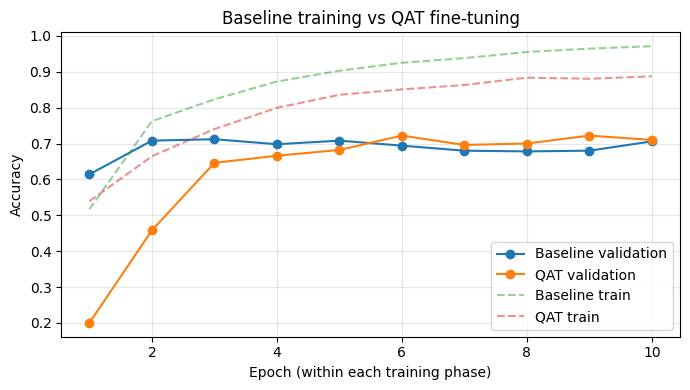

,Stage,Epoch,Train Acc (%),Val Acc (%),Train Loss,Val Loss
0,Baseline (best-val epoch),3,82.311,71.2,0.512,0.823
1,QAT fine-tuned (best-val epoch),6,85.089,72.2,0.433,0.799


In [14]:
hb, hq = baseline_history.history, qat_history.history

plt.figure(figsize=(7, 4))
plt.plot(range(1, BASELINE_EPOCHS + 1), hb["val_accuracy"], marker="o", label="Baseline validation")
plt.plot(range(1, QAT_EPOCHS + 1), hq["val_accuracy"], marker="o", label="QAT validation")
plt.plot(range(1, BASELINE_EPOCHS + 1), hb["accuracy"], "--", alpha=0.5, label="Baseline train")
plt.plot(range(1, QAT_EPOCHS + 1), hq["accuracy"], "--", alpha=0.5, label="QAT train")
plt.xlabel("Epoch (within each training phase)"); plt.ylabel("Accuracy")
plt.title("Baseline training vs QAT fine-tuning"); plt.grid(alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()

bb, qb = baseline_best.best_epoch - 1, qat_best.best_epoch - 1
summary = pd.DataFrame({
    "Stage": ["Baseline (best-val epoch)", "QAT fine-tuned (best-val epoch)"],
    "Epoch": [bb + 1, qb + 1],
    "Train Acc (%)": [hb["accuracy"][bb] * 100, hq["accuracy"][qb] * 100],
    "Val Acc (%)":   [hb["val_accuracy"][bb] * 100, hq["val_accuracy"][qb] * 100],
    "Train Loss":    [hb["loss"][bb], hq["loss"][qb]],
    "Val Loss":      [hb["val_loss"][bb], hq["val_loss"][qb]],
}).round(3)
display(summary)

### 12. Convert QAT Model to Full INT8 TFLite

The QAT model is converted to full INT8 TFLite with `int8` input/output. The cell first tries the conversion without a representative dataset; if the converter rejects it, it retries with the representative training samples and prints which case occurred. The result is then verified as full INT8.

In [15]:
def convert_qat(use_representative_dataset):
    converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    if use_representative_dataset:
        converter.representative_dataset = representative_dataset
    return converter.convert()

qat_used_representative_dataset = False
try:
    tflite_qat = convert_qat(use_representative_dataset=False)
except Exception as e:
    print("Conversion without representative dataset failed:", str(e)[:200])
    print("Retrying WITH representative dataset ...")
    tflite_qat = convert_qat(use_representative_dataset=True)
    qat_used_representative_dataset = True

with open("model_qat_int8.tflite", "wb") as f:
    f.write(tflite_qat)

print("Representative dataset used for QAT conversion:", qat_used_representative_dataset)
print(f"model_qat_int8.tflite saved: {get_size_kb('model_qat_int8.tflite'):.2f} KB")
in_dtype, out_dtype = inspect_tflite("model_qat_int8.tflite")
assert in_dtype == np.int8 and out_dtype == np.int8, "QAT model is not full INT8"

Conversion without representative dataset failed: For full integer quantization, a `representative_dataset` must be specified.
Retrying WITH representative dataset ...


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Representative dataset used for QAT conversion: True
model_qat_int8.tflite saved: 616.97 KB
Input  dtype: int8 | (scale, zero_point) = (0.007843137718737125, 0)
Output dtype: int8 | (scale, zero_point) = (0.00390625, -128)
Tensor dtypes in model: {'int8': 119, 'int32': 54}


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### 13. Evaluate QAT Model

The fine-tuned QAT Keras model is first evaluated on the test set, then `model_qat_int8.tflite` is evaluated with the same interpreter, test images and benchmarking method as the other two models.

In [16]:
_, qat_keras_acc = qat_model.evaluate(test_ds, verbose=0)
print(f"Float32 Keras test accuracy         : {float_keras_acc * 100:.2f}%")
print(f"QAT Keras (fake-quant) test accuracy: {qat_keras_acc * 100:.2f}%")

acc, lat = evaluate_tflite("model_qat_int8.tflite", test_images, test_labels)
results["QAT Full INT8"] = {"Size (KB)": get_size_kb("model_qat_int8.tflite"),
                            "Test Accuracy (%)": acc, "Avg Latency (ms)": lat}
print("QAT INT8 ->", {k: round(v, 3) for k, v in results["QAT Full INT8"].items()})

Float32 Keras test accuracy         : 71.30%
QAT Keras (fake-quant) test accuracy: 72.80%
QAT INT8 -> {'Size (KB)': 616.969, 'Test Accuracy (%)': np.float64(73.0), 'Avg Latency (ms)': 0.748}


### 14. Compare the Three Models

All values below are the measured results from the previous steps.

Model,Size (KB),Test Accuracy (%),Avg Latency (ms)
Float32 Baseline,1596.960000,71.300000,0.475000
PTQ Full INT8,609.980000,46.300000,0.758000
QAT Full INT8,616.970000,73.000000,0.748000


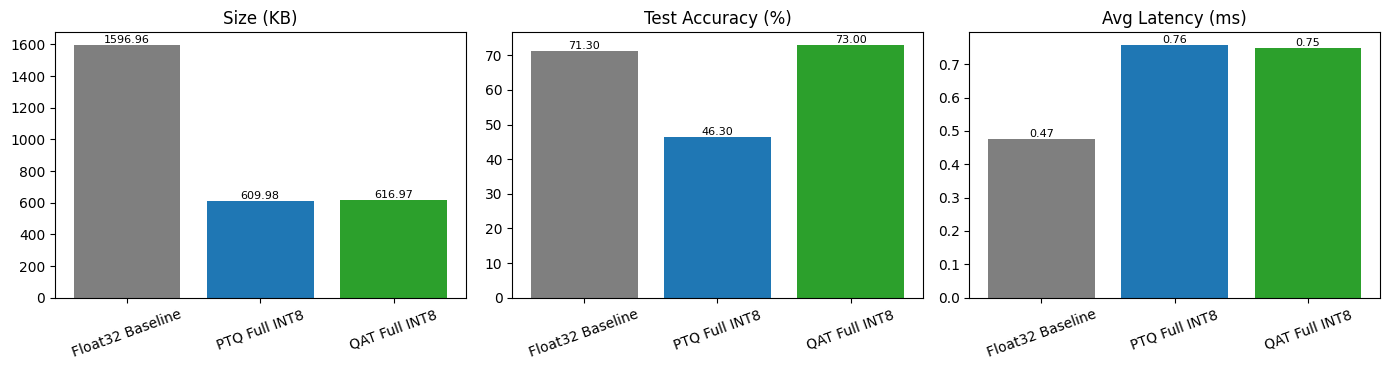

In [17]:
results_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
results_df = results_df[["Model", "Size (KB)", "Test Accuracy (%)", "Avg Latency (ms)"]]
display(results_df.round({"Size (KB)": 2, "Test Accuracy (%)": 2, "Avg Latency (ms)": 3}).style.hide(axis="index"))

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
colors = ["tab:gray", "tab:blue", "tab:green"]
for a, col in zip(ax, ["Size (KB)", "Test Accuracy (%)", "Avg Latency (ms)"]):
    bars = a.bar(results_df["Model"], results_df[col], color=colors)
    a.set_title(col)
    a.tick_params(axis="x", rotation=20)
    a.bar_label(bars, fmt="%.2f", fontsize=8)
plt.tight_layout(); plt.show()

## Lab Questions

**1. Why does Post-Training Quantization reduce model accuracy?**  
PTQ converts a model that was trained in float32 to 8-bit integers without any retraining. Weights and activations get rounded to only 256 levels, and activation ranges are estimated from a small calibration set (100 images here), so values outside those ranges are clipped. The model never saw this rounding noise during training, and the small errors add up over the many layers of MobileNetV2 (its depthwise convolutions and ReLU6 layers are known to be sensitive to quantization), which can lower accuracy.

**2. What does QAT simulate during training, and how does this help the model?**  
QAT inserts fake-quantization nodes that quantize and then dequantize weights and activations in the forward pass, so the network experiences INT8 rounding and clipping while still computing in float. In the backward pass the gradient passes through the rounding step (straight-through estimator). This lets the weights and the activation ranges adapt to the INT8 error, so the converted INT8 model loses less accuracy.

**3. Was a representative dataset required to convert the QAT model? Justify your answer.**  
Yes. In this experiment, a representative dataset was required to convert the QAT model to full INT8 TFLite. The first conversion attempt without it failed, because the converter required calibration data for full integer quantization. After the representative training samples were supplied, the conversion succeeded. (For PTQ the same dataset is used to calibrate activation ranges.)

**4. Did QAT change the size of the INT8 model? Explain.**  
QAT did not significantly change the INT8 model size. The PTQ model was 609.98 KB, while the QAT model was 616.97 KB. Both use the same INT8 representation, so their sizes are similar; the small difference can result from differences in the converted TFLite graph and metadata.

**5. Under what conditions is PTQ sufficient, so that QAT is not needed?**  
PTQ is enough when the accuracy drop after INT8 conversion is within what the application can tolerate, which is often the case for larger or over-parameterised models that are robust to rounding. It also works well when a good calibration set is available, when the training pipeline/data is not available or retraining time is limited, and when the model has no layers that are especially sensitive to quantization. If the PTQ model already matches the Float32 accuracy closely, QAT adds training cost without a real benefit.

## Result / Conclusion

The text below is generated from the measured values in the comparison table.

In [18]:
from IPython.display import Markdown, display

r = results_df.set_index("Model")
fl, pt, qt = r.loc["Float32 Baseline"], r.loc["PTQ Full INT8"], r.loc["QAT Full INT8"]
A, S, T = "Test Accuracy (%)", "Size (KB)", "Avg Latency (ms)"

def rel(a, b, more, less, same="the same as"):
    return more if a > b else less if a < b else same

best_model = r[A].idxmax()
note = (" Because QAT includes extra fine-tuning epochs, an accuracy above Float32 reflects additional training and not quantization itself."
        if qt[A] > fl[A] else "")

conclusion = f"""
The Float32 baseline reached {fl[A]:.2f}% accuracy ({fl[S]:.2f} KB, {fl[T]:.3f} ms), PTQ INT8 reached {pt[A]:.2f}% ({pt[S]:.2f} KB, {pt[T]:.3f} ms) and QAT INT8 reached {qt[A]:.2f}% ({qt[S]:.2f} KB, {qt[T]:.3f} ms). Both INT8 models are about {fl[S] / qt[S]:.1f}x smaller than Float32. QAT accuracy was {abs(qt[A] - pt[A]):.2f} points {rel(qt[A], pt[A], 'higher than', 'lower than')} PTQ and {abs(qt[A] - fl[A]):.2f} points {rel(qt[A], fl[A], 'higher than', 'lower than')} Float32; the highest accuracy in this run was {best_model} (a result for this run on 1000 test images, not a general guarantee).{note} The QAT model was {rel(qt[S], pt[S], 'larger', 'smaller', 'the same size')} than the PTQ model ({qt[S]:.2f} vs {pt[S]:.2f} KB) and its latency was {rel(qt[T], pt[T], 'higher', 'lower', 'equal')} ({qt[T]:.3f} vs {pt[T]:.3f} ms). In this TFLite benchmark the PTQ and QAT models were {rel(pt[T], fl[T], 'slower', 'faster', 'as fast as')} and {rel(qt[T], fl[T], 'slower', 'faster', 'as fast as')} than Float32 respectively. This shows the trade-off between accuracy, model size and latency.
"""
display(Markdown(conclusion))


The Float32 baseline reached 71.30% accuracy (1596.96 KB, 0.475 ms), PTQ INT8 reached 46.30% (609.98 KB, 0.758 ms) and QAT INT8 reached 73.00% (616.97 KB, 0.748 ms). Both INT8 models are about 2.6x smaller than Float32. QAT accuracy was 26.70 points higher than PTQ and 1.70 points higher than Float32; the highest accuracy in this run was QAT Full INT8 (a result for this run on 1000 test images, not a general guarantee). Because QAT includes extra fine-tuning epochs, an accuracy above Float32 reflects additional training and not quantization itself. The QAT model was larger than the PTQ model (616.97 vs 609.98 KB) and its latency was lower (0.748 vs 0.758 ms). In this TFLite benchmark the PTQ and QAT models were slower and slower than Float32 respectively. This shows the trade-off between accuracy, model size and latency.
